## TF-IDF Vectorization

TF stands for term frequency = (number of times word occured in doc / total number of words in doc)

IDF stands for inverse document frequency  = log(Total docs/1 + Number of docs in which this word present)

TF-IDF = TF x IDF

It tells how much important a word is wrt to document in a corpus.

It down-weights common words like 'the', 'and' which used to occur frequently in docs.

In [ ]:
import numpy as np

In [1]:
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "A brown fox was seen running across the field.",
    "The hunter spotted a brown fox near the riverbank.",
    "At night, the brown fox sneaks quietly into the farm.",
    "The villagers believe the brown fox is very clever."
]

In [2]:
# remove punctuation and convert words to lower
import string
punct_string = string.punctuation
print(punct_string)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [6]:
for punct in punct_string:
    for i, sent in enumerate(sentences):
        s1 = sent.replace(punct, '')
        sentences[i] = s1

for sent in sentences:
    print(sent)

The quick brown fox jumps over the lazy dog
A brown fox was seen running across the field
The hunter spotted a brown fox near the riverbank
At night the brown fox sneaks quietly into the farm
The villagers believe the brown fox is very clever


In [7]:
# convert to lower()
import nltk 
from nltk.tokenize import word_tokenize

tokenized_sent = [word_tokenize(sent) for sent in sentences]
print(tokenized_sent)

[['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog'], ['A', 'brown', 'fox', 'was', 'seen', 'running', 'across', 'the', 'field'], ['The', 'hunter', 'spotted', 'a', 'brown', 'fox', 'near', 'the', 'riverbank'], ['At', 'night', 'the', 'brown', 'fox', 'sneaks', 'quietly', 'into', 'the', 'farm'], ['The', 'villagers', 'believe', 'the', 'brown', 'fox', 'is', 'very', 'clever']]


In [9]:
sentences_lowered = []

for sent in tokenized_sent:
    new_sent = [word.lower() for word in sent]
    sentences_lowered.append(new_sent)

for sent in sentences_lowered:
    print(sent)

['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
['a', 'brown', 'fox', 'was', 'seen', 'running', 'across', 'the', 'field']
['the', 'hunter', 'spotted', 'a', 'brown', 'fox', 'near', 'the', 'riverbank']
['at', 'night', 'the', 'brown', 'fox', 'sneaks', 'quietly', 'into', 'the', 'farm']
['the', 'villagers', 'believe', 'the', 'brown', 'fox', 'is', 'very', 'clever']


In [32]:
# making vocabulary 
word2idx = {}
idx2word = {}
# taking count of word across docs
word2doc = {}
wordset = set()
idx = 0
for sent in sentences_lowered:
    for i, word in enumerate(sent):
        if word not in wordset:
            word2idx[word] = idx 
            idx2word[idx] = word
            wordset.add(word)
            idx += 1
            word2doc[word] = 0

for word, idx in word2idx.items():
    for sent in sentences_lowered:
        if word in sent:
            word2doc[word] += 1

In [33]:
# priting word2doc and word2idx 

print(f"Word 2 doc : {word2doc}")
print(f"Word 2 idx : {word2idx}")

Word 2 doc : {'the': 5, 'quick': 1, 'brown': 5, 'fox': 5, 'jumps': 1, 'over': 1, 'lazy': 1, 'dog': 1, 'a': 2, 'was': 1, 'seen': 1, 'running': 1, 'across': 1, 'field': 1, 'hunter': 1, 'spotted': 1, 'near': 1, 'riverbank': 1, 'at': 1, 'night': 1, 'sneaks': 1, 'quietly': 1, 'into': 1, 'farm': 1, 'villagers': 1, 'believe': 1, 'is': 1, 'very': 1, 'clever': 1}
Word 2 idx : {'the': 0, 'quick': 1, 'brown': 2, 'fox': 3, 'jumps': 4, 'over': 5, 'lazy': 6, 'dog': 7, 'a': 8, 'was': 9, 'seen': 10, 'running': 11, 'across': 12, 'field': 13, 'hunter': 14, 'spotted': 15, 'near': 16, 'riverbank': 17, 'at': 18, 'night': 19, 'sneaks': 20, 'quietly': 21, 'into': 22, 'farm': 23, 'villagers': 24, 'believe': 25, 'is': 26, 'very': 27, 'clever': 28}


In [34]:
# creating vectors for TF-IDF 

tf_vectors = []

for sent in sentences_lowered:
    vector = np.zeros((len(word2idx)))
    total_words_in_sent = len(sent)
    for word in sent:
        vector[word2idx[word]] += 1
    
    vector = vector/total_words_in_sent
    vector = np.round(vector, 2)
    tf_vectors.append(vector)

for vector in tf_vectors:
    print(vector)

[0.22 0.11 0.11 0.11 0.11 0.11 0.11 0.11 0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.  ]
[0.11 0.   0.11 0.11 0.   0.   0.   0.   0.11 0.11 0.11 0.11 0.11 0.11
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.  ]
[0.22 0.   0.11 0.11 0.   0.   0.   0.   0.11 0.   0.   0.   0.   0.
 0.11 0.11 0.11 0.11 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.  ]
[0.2 0.  0.1 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.1 0.1 0.1 0.1 0.1 0.1 0.  0.  0.  0.  0. ]
[0.22 0.   0.11 0.11 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.11 0.11 0.11 0.11
 0.11]


In [36]:
total_sentences = len(sentences_lowered)
tf_idf_vectors = []
# making tf*idf 

for vector in tf_vectors:
    idfs = []
    for idx in range(len(word2idx)):
        idf = np.log(total_sentences/(1+word2doc[idx2word[idx]]))
        idfs.append(idf)
    
    idf_arr = np.array(idfs)
    vector = np.multiply(vector, idf_arr)
    vector = np.round(vector, 2)
    tf_idf_vectors.append(vector)

for vector in tf_idf_vectors:
    print(vector)



[-0.04  0.1  -0.02 -0.02  0.1   0.1   0.1   0.1   0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.  ]
[-0.02  0.   -0.02 -0.02  0.    0.    0.    0.    0.06  0.1   0.1   0.1
  0.1   0.1   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.  ]
[-0.04  0.   -0.02 -0.02  0.    0.    0.    0.    0.06  0.    0.    0.
  0.    0.    0.1   0.1   0.1   0.1   0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.  ]
[-0.04  0.   -0.02 -0.02  0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.09  0.09  0.09  0.09  0.09  0.09
  0.    0.    0.    0.    0.  ]
[-0.04  0.   -0.02 -0.02  0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.1   0.1   0.1   0.1   0.1 ]


## Word2Vec

Word can capture semantic relationship and can be respresented as n-dimensional dense embedding

Two approaches are used : 
1) CBOW - Continuous Bag of Words (predicting center word from neighbouring words)
2) Skip gram - Predicting neighbouring words using center word

### CBOW Implementation

In [25]:
# We are going to train a model with only few words so we can see what is happening behind the architecture
text = "The quick brown fox leapt gracefully over the lazy dog while bright sunlight filtered through tall trees, casting shimmering patterns across the forest floor; birds chirped softly, flowers swayed gently in the cool breeze, and distant mountains stood tall, reminding everyone of nature’s timeless beauty, peace, and endless mysteries."


So what we are going to do first - clean the text 

In [26]:
import string 
# punctuations 
punct_string = string.punctuation

# removing punctuation
for punct in punct_string:
    text = text.replace(punct, '')

print(text)

The quick brown fox leapt gracefully over the lazy dog while bright sunlight filtered through tall trees casting shimmering patterns across the forest floor birds chirped softly flowers swayed gently in the cool breeze and distant mountains stood tall reminding everyone of nature’s timeless beauty peace and endless mysteries


In [27]:
# lets tokenize these words
import nltk 
from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)
tokens = [word.lower() for word in tokens]
print(tokens)

['the', 'quick', 'brown', 'fox', 'leapt', 'gracefully', 'over', 'the', 'lazy', 'dog', 'while', 'bright', 'sunlight', 'filtered', 'through', 'tall', 'trees', 'casting', 'shimmering', 'patterns', 'across', 'the', 'forest', 'floor', 'birds', 'chirped', 'softly', 'flowers', 'swayed', 'gently', 'in', 'the', 'cool', 'breeze', 'and', 'distant', 'mountains', 'stood', 'tall', 'reminding', 'everyone', 'of', 'nature', '’', 's', 'timeless', 'beauty', 'peace', 'and', 'endless', 'mysteries']


In [28]:
# lets make vocabulary
word2idx = {}
idx2word = {} 

unique_words = set() 
idx = 0
for word in tokens:
    if word not in unique_words:
        word2idx[word] = idx 
        idx2word[idx] = word 
        idx += 1 
        unique_words.add(word)

print(f"Vocab size : {len(unique_words)}")

Vocab size : 46


In [29]:
# now we need to prepare data for CBOW
# [n_word-2, n_word-1, center_word, n_word+1, n_word+2]
# predictors = [n_word-2, n_word-1, n_word+1, n_word+2]
# output = [center_word]
cbow_data = []

for i in range(2, len(tokens)-2):
  data = []
  # n_word-2
  data.append(tokens[i-2])
  # n_word-1
  data.append(tokens[i-1])
  # center_word
  data.append(tokens[i])
  # n_word+1
  data.append(tokens[i+1])
  # n_word+2
  data.append(tokens[i+2])

  cbow_data.append(data)

print(f"Total training examples : {len(cbow_data)}")

# lets print some examples
examples = 4
for i in range(examples):
  print(cbow_data[i])

Total training examples : 47
['the', 'quick', 'brown', 'fox', 'leapt']
['quick', 'brown', 'fox', 'leapt', 'gracefully']
['brown', 'fox', 'leapt', 'gracefully', 'over']
['fox', 'leapt', 'gracefully', 'over', 'the']


In [6]:
# now lets make predictors and outputs
predictors = []
labels = []

for data in cbow_data:
  a, b, c, d, e = data
  X = [a, b, d, e]
  predictors.append(X)
  labels.append(c)

# lets print some examples
examples = 4

for i in range(examples):
  print(f"Predictors : {predictors[i]}, Label : {labels[i]}")

Predictors : ['the', 'quick', 'fox', 'leapt'], Label : brown
Predictors : ['quick', 'brown', 'leapt', 'gracefully'], Label : fox
Predictors : ['brown', 'fox', 'gracefully', 'over'], Label : leapt
Predictors : ['fox', 'leapt', 'over', 'the'], Label : gracefully


In [131]:
# lets make vectors of predictors and labels 
import torch 

predictors_vector = []
labels_vector = []

for predictor, label in zip(predictors, labels):
    preds = []
    for pred in predictor:
        l1 = torch.zeros((1, len(word2idx)))
        l1[0][word2idx[pred]] = 1
        preds.append(l1)
    preds = torch.stack(preds, dim=1).squeeze(0)
    predictors_vector.append(preds)

    labels_vector.append(torch.tensor([word2idx[label]]))

# printing 1 example
for i in range(2):
    print(f"Predictor : {predictors_vector[i].shape}")
    print(f"Label : {labels_vector[i]}")

Predictor : torch.Size([4, 46])
Label : tensor([2])
Predictor : torch.Size([4, 46])
Label : tensor([3])


Input layer = 4 X V 

Hidden layer = V X N 

Hidden2 layer = N X V 

Output = Average of Hidden 2 (1 x V) 

In [132]:
# Now lets build a layer that would get trained to learn vector embeddings of word 
import torch.nn as nn 
import torch.nn.functional as F 

embedding_dim = 20
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__() 
        self.layer1 = nn.Linear(len(word2idx), 20)
        self.layer2 = nn.Linear(20, len(word2idx))

    def forward(self, x):
        h1 = F.relu(self.layer1(x))
        h2 = self.layer2(h1)

        out = torch.mean(h2, dim=0, keepdim=True)
        probs = F.softmax(out, dim=1)
        return probs

model = NeuralNetwork()

In [153]:
t1 = torch.rand((2, 3))
t2 = torch.rand((1, 3))
print(t1)
torch.mean(t1, dim=0, keepdim=True)

tensor([[0.6859, 0.0876, 0.6878],
        [0.3851, 0.9528, 0.3562]])


tensor([[0.5355, 0.5202, 0.5220]])

In [133]:
# here how we can access the weight of each layer
embeddings = (model.layer1.weight.T)

print(f"Embedding of word '{idx2word[0]}' : {embeddings[0]}")

Embedding of word 'the' : tensor([-0.1206,  0.1046,  0.0711,  0.1114, -0.1245, -0.0563, -0.0886,  0.1445,
         0.0349, -0.1374,  0.1274, -0.0159, -0.0263, -0.0935,  0.0929,  0.0795,
        -0.0930,  0.0733,  0.0209,  0.0772], grad_fn=<SelectBackward0>)


In [134]:
# lets try with a dummy input variable 
X_dummy = torch.rand((4, len(word2idx)))
probs = model(X_dummy)
print(f"Probabilities : {probs.argmax()}")


Probabilities : 4


## Hyperparameters 

In [135]:
epochs = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [137]:
model.train()
losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    
    for X, y in zip(predictors_vector, labels_vector):
        
        optimizer.zero_grad()           # reset grads
        probs = model(X)       # forward
        loss = loss_fn(probs, y)        # compute loss
        loss.backward()                 # backward
        optimizer.step()                # update weights
        
        epoch_loss += loss.item()
    
    losses.append(epoch_loss)
    print(f"Epoch : {epoch+1}, loss : {epoch_loss:.4f}")

Epoch : 1, loss : 180.0487
Epoch : 2, loss : 179.8774
Epoch : 3, loss : 179.6222
Epoch : 4, loss : 178.4908
Epoch : 5, loss : 177.2113
Epoch : 6, loss : 176.4334
Epoch : 7, loss : 174.7941
Epoch : 8, loss : 172.1169
Epoch : 9, loss : 168.6570
Epoch : 10, loss : 164.2703


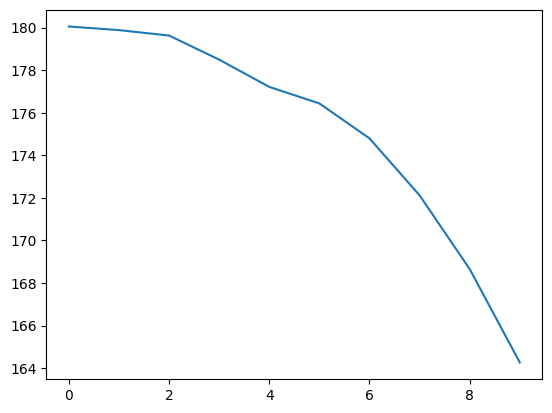

In [141]:
import matplotlib.pyplot as plt
plt.plot(losses)

Now its time to check embeddings

In [144]:
embeddings = model.layer1.weight.T
print(embeddings.shape)

for i in range(46):
    print(f"Word : '{idx2word[i]}', Embedding : {embeddings[i]}")

torch.Size([46, 20])
Word : 'the', Embedding : tensor([-0.1206,  0.1046, -0.3780,  1.3725, -0.7148, -0.5765, -0.5127, -0.8814,
         0.5298, -0.3111,  2.6717, -0.4750, -0.5653, -0.0935,  2.3731, -0.5346,
        -0.7830,  0.0733, -0.6129, -0.5930], grad_fn=<SelectBackward0>)
Word : 'quick', Embedding : tensor([-0.1089, -0.1089,  0.6213, -0.5891,  0.8106, -0.2098, -0.5461,  0.0212,
         0.9836,  0.9191,  0.0362,  0.1316,  0.7155, -0.0334, -0.4982,  0.8333,
        -0.6730,  0.0974, -0.4712,  0.2589], grad_fn=<SelectBackward0>)
Word : 'brown', Embedding : tensor([ 0.0323,  0.0444, -0.1280, -0.5689,  0.0741,  0.5973, -0.5054, -0.8318,
         1.2862,  0.4522, -0.5415, -0.0683, -0.4397, -0.0770, -0.4609, -0.2120,
        -0.3415,  0.0781, -0.3246, -0.3568], grad_fn=<SelectBackward0>)
Word : 'fox', Embedding : tensor([-0.0756, -0.0592,  0.6006, -0.4881, -0.6373, -0.1106, -0.5613, -0.1497,
         1.1922, -0.0609,  0.7880, -0.4072,  0.9037, -0.0797, -0.4802,  0.2889,
        -0.6322

This is how CBOW works my friend